# Corelacion de variables

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
DATA_IMPUTED = "../../data/input_data/data_imputed.csv"

In [11]:
def load_data():
    """Carga los datos desde el archivo CSV y devuelve un DataFrame de pandas."""
    try:
        data = pd.read_csv(DATA_IMPUTED)
        return data
    except FileNotFoundError:
        print(f"Error: El archivo {DATA_IMPUTED} no se encontró.")
        return None
    except Exception as e:
        print(f"Error al cargar los datos: {e}")
        return None

In [12]:
df = load_data()

In [13]:
# Seleccionar solo variables numéricas
corr = df.corr(numeric_only=True)

# Mostrar matriz
corr

,CVE_ENT,CVE_MUN,SEXO_MAP,ESTATUS_MAP,FECHA_NACIMIENTO_CONFIDENCIAL,FECHA_DESAPARICION_CONFIDENCIAL,FECHA_REGISTRO_CONFIDENCIAL
CVE_ENT,1.000000,0.145739,-0.050226,-0.060741,-0.053122,-0.053122,-0.053122
CVE_MUN,0.145739,1.000000,0.892369,0.900078,0.916297,0.916297,0.916297
SEXO_MAP,-0.050226,0.892369,1.000000,0.948135,0.967422,0.967422,0.967422
ESTATUS_MAP,-0.060741,0.900078,0.948135,1.000000,0.981052,0.981052,0.981052
FECHA_NACIMIENTO_CONFIDENCIAL,-0.053122,0.916297,0.967422,0.981052,1.000000,1.000000,1.000000
FECHA_DESAPARICION_CONFIDENCIAL,-0.053122,0.916297,0.967422,0.981052,1.000000,1.000000,1.000000
FECHA_REGISTRO_CONFIDENCIAL,-0.053122,0.916297,0.967422,0.981052,1.000000,1.000000,1.000000


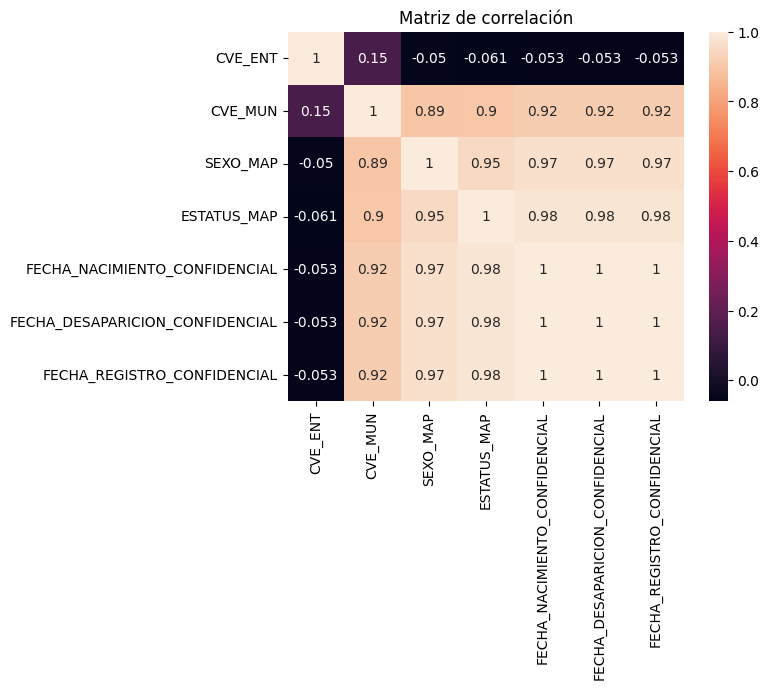

In [14]:
plt.figure()

sns.heatmap(corr, annot=True)

plt.title("Matriz de correlación")
plt.show()

In [19]:
corr_unstack = corr.unstack()

# Quitar correlaciones consigo mismo
corr_unstack = corr_unstack[corr_unstack != 1]

# Ordenar
corr_ordenadas = corr_unstack.sort_values(ascending=False)

In [18]:
print("Correlaciones más fuertes:")
corr_ordenadas.head(10)   # más fuertes

Correlaciones más fuertes:


FECHA_REGISTRO_CONFIDENCIAL      ESTATUS_MAP                        0.981052
FECHA_DESAPARICION_CONFIDENCIAL  ESTATUS_MAP                        0.981052
ESTATUS_MAP                      FECHA_REGISTRO_CONFIDENCIAL        0.981052
FECHA_NACIMIENTO_CONFIDENCIAL    ESTATUS_MAP                        0.981052
ESTATUS_MAP                      FECHA_DESAPARICION_CONFIDENCIAL    0.981052
                                 FECHA_NACIMIENTO_CONFIDENCIAL      0.981052
SEXO_MAP                         FECHA_NACIMIENTO_CONFIDENCIAL      0.967422
FECHA_DESAPARICION_CONFIDENCIAL  SEXO_MAP                           0.967422
FECHA_REGISTRO_CONFIDENCIAL      SEXO_MAP                           0.967422
FECHA_NACIMIENTO_CONFIDENCIAL    SEXO_MAP                           0.967422
dtype: float64

In [20]:
print("Correlaciones más debiles:")
corr_ordenadas.tail(10)   # más débiles

Correlaciones más debiles:


CVE_ENT                          SEXO_MAP                          -0.050226
SEXO_MAP                         CVE_ENT                           -0.050226
FECHA_DESAPARICION_CONFIDENCIAL  CVE_ENT                           -0.053122
CVE_ENT                          FECHA_NACIMIENTO_CONFIDENCIAL     -0.053122
                                 FECHA_DESAPARICION_CONFIDENCIAL   -0.053122
                                 FECHA_REGISTRO_CONFIDENCIAL       -0.053122
FECHA_REGISTRO_CONFIDENCIAL      CVE_ENT                           -0.053122
FECHA_NACIMIENTO_CONFIDENCIAL    CVE_ENT                           -0.053122
CVE_ENT                          ESTATUS_MAP                       -0.060741
ESTATUS_MAP                      CVE_ENT                           -0.060741
dtype: float64